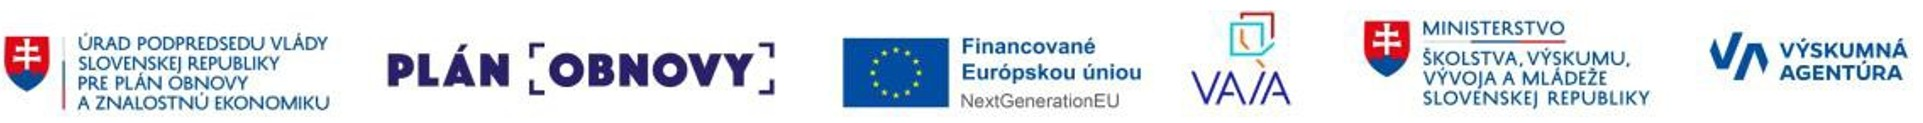

## Identifikácia projektu

| | |
|---|---|
| **Názov projektu** | A Statistical Approach to Monitor Quantisation in Neural Network Training |
| **Akronym projektu** | SAMQ-NN |
| **Kód projektu** | 09I03-03-V04-00562 |
| **Program** | Plán obnovy a odolnosti Slovenskej republiky |
| **Komponent** | 9. Efektívnejšie riadenie a posilnenie financovania výskumu, vývoja a inovácií v rámci Plánu obnovy a odolnosti Slovenskej republiky |
| **Investícia** | 3. Excelentná veda |
| **Schéma štátnej pomoci** | Schéma štátnej pomoci na podporu výskumu, vývoja a inovácií v rámci Komponentu 9 Plánu obnovy a odolnosti Slovenskej republiky, č. SA.106633 |
| **Začiatok projektu** | 06/2024 |
| **Koniec realizácie** | 05/2026 |
| **Zodpovedný riešiteľ** | Ing. Roman Budjač, PhD. |

# D11 – Možnosti riešenia: Správa z prezentácie na seminári v rámci WP3

Tento notebook ilustruje **koncepty zo seminára D11** na malých, samostatných príkladoch (numpy + scipy, beží na CPU). Nejde o úplnú implementáciu — tá je predmetom **D12**. Cieľom je ukázať *varianty* riešenia:

- **Možnosť A**: metódy na porovnávanie rozdelení váh (KL, JS, kosínusová, Wassersteinova),
- správanie metrík naprieč bitovými hĺbkami,
- **Možnosť B**: kvantizácia per-tensor vs per-channel,
- **Možnosť C**: využitie indexu (globálny / per-layer, automatický výber bitovej hĺbky).

## Príprava: kvantizácia a referenčné váhy

Jednoduchá uniformná kvantizácia: zaokrúhlenie váh na mriežku s 2ᵇ úrovňami (min–max, per-tensor). `w_ref` predstavuje plne presný (FP32) referenčný model.

In [1]:
import numpy as np
rng = np.random.default_rng(0)

def quantize(w, bits):
    "Uniformná kvantizácia per-tensor: zaokrúhli hodnoty na mriežku 2^bits (min-max)."
    lo, hi = float(w.min()), float(w.max())
    if hi == lo:
        return w.copy()
    q = 2 ** bits - 1
    s = (hi - lo) / q
    return np.round((w - lo) / s) * s + lo

# referenčné (FP32) váhy a ich 8-bitová kvantizovaná kópia
w_ref = rng.normal(0.0, 0.10, size=5000)
w_q8  = quantize(w_ref, 8)

print(f"referencia : rozsah [{w_ref.min():.3f}, {w_ref.max():.3f}], "
      f"počet rôznych hodnôt = {len(np.unique(w_ref))}")
print(f"8-bitová   : počet rôznych hodnôt = {len(np.unique(w_q8))}  (max 2^8 = 256)")

referencia : rozsah [-0.390, 0.326], počet rôznych hodnôt = 5000
8-bitová   : počet rôznych hodnôt = 210  (max 2^8 = 256)


## Možnosť A: metódy na porovnávanie rozdelení

Spoločný postup: z oboch množín váh sa zostavia histogramy na **rovnakej mriežke binov**, normalizujú sa na pravdepodobnostné rozdelenia (s malým ε) a porovnajú sa zvolenou mierou. Wassersteinova vzdialenosť sa počíta priamo zo vzoriek.

In [2]:
from scipy.stats import wasserstein_distance

def to_hist(x, edges, eps=1e-10):
    "Normalizovaný histogram na pevných hraniciach binov (+ eps proti nulám)."
    h, _ = np.histogram(x, bins=edges)
    h = h.astype(float) + eps
    return h / h.sum()

def kl_div(p, q):                       # asymetrická, neohraničená (bity)
    return float(np.sum(p * np.log2(p / q)))

def js_div(p, q):                       # symetrická, ohraničená [0,1] (bity)
    m = 0.5 * (p + q)
    return 0.5 * kl_div(p, m) + 0.5 * kl_div(q, m)

def cosine_sim(p, q):                   # orientácia rozdelení
    return float(p @ q / (np.linalg.norm(p) * np.linalg.norm(q)))

def index(p_samples, q_samples, metric="js", n_bins=100):
    "Štatistický index podobnosti medzi dvoma množinami váh."
    lo = min(p_samples.min(), q_samples.min())
    hi = max(p_samples.max(), q_samples.max())
    edges = np.linspace(lo, hi, n_bins + 1)
    P, Q = to_hist(p_samples, edges), to_hist(q_samples, edges)
    return {"kl": kl_div(P, Q), "js": js_div(P, Q),
            "cosine": cosine_sim(P, Q),
            "wasserstein": wasserstein_distance(p_samples, q_samples)}[metric]

# porovnanie 4-bitovej kvantizovanej kópie s referenciou všetkými štyrmi metrikami
w_q4 = quantize(w_ref, 4)
for m in ("kl", "js", "cosine", "wasserstein"):
    print(f"  {m:12s}: {index(w_ref, w_q4, m):.5f}")

  kl          : 33.29830
  js          : 0.67912
  cosine      : 0.38679
  wasserstein : 0.01189


## Ako sa metriky správajú naprieč bitovými hĺbkami

Výsledky naznačujú, že hrubšia kvantizácia, reprezentovaná nižším počtom bitov, vedie k väčšej odchýlke rozdelenia kvantizovaných váh od pôvodného rozdelenia. Tento efekt sa prejavuje rastom navrhovaného indexu. Keďže analyzované miery sú navzájom silne korelované, voľba konkrétnej metriky podstatne neovplyvňuje konečný záver. Jensenova–Shannonova divergencia však predstavuje vhodnú praktickú voľbu vďaka svojmu ohraničenému rozsahu a ľahšej interpretovateľnosti.

 bity |       JS |       KL |  kosínus
    8 |   0.0080 |   0.0386 |   0.9800
    6 |   0.2134 |  14.0563 |   0.8011
    4 |   0.6791 |  33.2983 |   0.3868
    3 |   0.8204 |  36.7823 |   0.2355
    2 |   0.9055 |  38.3955 |   0.1475


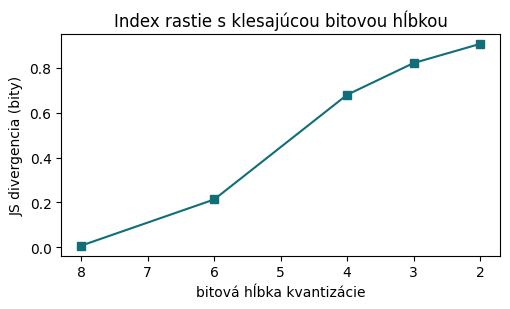

In [3]:
bit_widths = [8, 6, 4, 3, 2]   # ilustračné (vrátane medzihodnôt 6 a 3 na ukážku správania metriky)
print(f"{'bity':>5} | {'JS':>8} | {'KL':>8} | {'kosínus':>8}")
js_curve = []
for b in bit_widths:
    wq = quantize(w_ref, b)
    js, kl, cos = index(w_ref, wq, "js"), index(w_ref, wq, "kl"), index(w_ref, wq, "cosine")
    js_curve.append(js)
    print(f"{b:>5} | {js:>8.4f} | {kl:>8.4f} | {cos:>8.4f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(5.2, 3.2))
plt.plot(bit_widths, js_curve, "s-", color="#0F6E78")
plt.gca().invert_xaxis()
plt.xlabel("bitová hĺbka kvantizácie"); plt.ylabel("JS divergencia (bity)")
plt.title("Index rastie s klesajúcou bitovou hĺbkou"); plt.tight_layout(); plt.show()

## Možnosť B: kvantizácia per-tensor vs per-channel

Kvantizácia per-tensor používa jedinú spoločnú škálu pre celý tenzor váh danej vrstvy, zatiaľ čo kvantizácia per-channel priraďuje samostatnú škálu každému výstupnému kanálu. Pri vrstvách, v ktorých sa rozsahy hodnôt medzi kanálmi výrazne líšia, poskytuje prístup per-channel presnejšiu aproximáciu pôvodných váh, čo sa prejavuje nižšou hodnotou navrhovaného indexu.

In [4]:
def quantize_per_channel(W, bits):
    "Kvantizuj každý výstupný kanál (posledná os) s vlastnou min-max škálou."
    out = np.empty_like(W)
    for c in range(W.shape[-1]):
        out[..., c] = quantize(W[..., c], bits)
    return out

# matica váh, ktorej kanály (stĺpce) majú veľmi rozdielne škály
scales = np.logspace(-2, 0, 64)                 # 0.01 .. 1.0
W = rng.normal(0.0, 1.0, size=(256, 64)) * scales

W_pt = quantize(W.ravel(), 4).reshape(W.shape)  # per-tensor (jedna škála)
W_pc = quantize_per_channel(W, 4)               # per-channel

print(f"per-tensor : globálny index JS = {index(W.ravel(), W_pt.ravel(), 'js'):.4f}")
print(f"per-channel: globálny index JS = {index(W.ravel(), W_pc.ravel(), 'js'):.4f}")
print("per-channel je presnejší (nižší index) -> robustný aj pre hlboké siete")

per-tensor : globálny index JS = 0.7689
per-channel: globálny index JS = 0.0123
per-channel je presnejší (nižší index) -> robustný aj pre hlboké siete


## Možnosť C: využitie indexu

**Granularita:** globálny index (cez všetky váhy) vs per-layer (odhalí najcitlivejšiu vrstvu).
**Úloha (prediktor):** pred tréningom vyber najnižšiu bitovú hĺbku, pri ktorej index zostáva pod prahom.

In [5]:
# niekoľko „vrstiev" s rôznymi tenzormi váh (demonštrácia)
layers = {
    "conv1": rng.normal(0, 0.10, (3, 3, 3, 16)),
    "conv2": rng.normal(0, 0.07, (3, 3, 16, 32)),
    "dense": rng.normal(0, 0.05, (128, 64)),
}

# globálny vs per-layer index - 4-bit
all_ref = np.concatenate([w.ravel() for w in layers.values()])
all_q   = np.concatenate([quantize(w, 4).ravel() for w in layers.values()])
print(f"globálny index (4-bit)   : JS = {index(all_ref, all_q, 'js'):.4f}\n")
print("per-layer index (4-bit):")
for name, w in layers.items():
    print(f"  {name:7s}: JS = {index(w.ravel(), quantize(w, 4).ravel(), 'js'):.4f}")

def auto_select_bitwidth(w, candidates=(4, 8, 16, 32), tau=0.01):
    "Prediktor: najnižšia bitová hĺbka, ktorej index zostáva pod prahom."
    for b in sorted(candidates):
        if index(w, quantize(w, b), "js") <= tau:
            return b
    return max(candidates)

print(f"\nauto_select_bitwidth(conv1, prah=0.01) -> {auto_select_bitwidth(layers['conv1'].ravel())}-bit")

globálny index (4-bit)   : JS = 0.3270

per-layer index (4-bit):
  conv1  : JS = 0.7295
  conv2  : JS = 0.6795
  dense  : JS = 0.6795

auto_select_bitwidth(conv1, prah=0.01) -> 16-bit


## Zhrnutie

- **Metrika:** JS divergencia ako primárna (ohraničená, vhodná na prahovanie); KL a kosínus ako doplnkové.
- **Granularita indexu:** globálna aj per-layer.
- **Úloha:** prediktor (výber bitovej hĺbky) aj monitor (počas tréningu).
- **Kvantizácia:** per-channel pre robustnosť pri hlbokých sieťach.

Tieto stavebné bloky tvoria základ implementácie **D12**; ostatné možnosti (Wasserstein, referencia medzi epochami, monitorovanie aktivácií) zostávajú ako potenciálne rozšírenia.